In [1]:
# Importing necessary libraries
import yfinance as yf
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score

In [2]:
# Importing the data through yfinance library
nse = yf.Ticker("^NSEI")
nse = nse.history(period="max")

<Axes: xlabel='Date'>

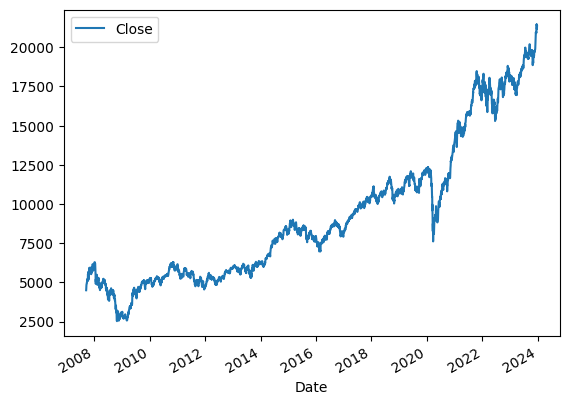

In [3]:
# Chart of NSE
nse.plot.line(y="Close", use_index=True)

In [4]:
# Feature Engineering
del nse['Dividends']
del nse['Stock Splits']
nse["tomorrow"] = nse["Close"].shift(-1)
nse["target"] = (nse["tomorrow"] > nse["Close"]).astype(int)
nse.to_csv('nse_data', index=True)

In [5]:
# Creating RandomForestClassifier model
model = RandomForestClassifier(n_estimators=200, min_samples_split=100, random_state=1)

In [6]:
# Splitting the data into train and test sets
train = nse.iloc[:-100]
test = nse.iloc[-100:]

In [7]:
# Defining features (x) and target (y)
x = ["Close", "Open", "High", "Low", "Volume"]
y = "target"

In [8]:
# Fitting the model
model.fit(train[x], train[y])

RandomForestClassifier(min_samples_split=100, n_estimators=200, random_state=1)

In [9]:
# Making predictions
preds = model.predict(test[x])
preds = pd.Series(preds, index=test.index)
precision_score(test[y], preds)

0.57

In [10]:
# Adding predictions to the test set
test['preds'] = preds
test.head()

/var/folders/10/4p6gdwfx3g74kjfj2_xqxz140000gn/T/ipykernel_6872/967206501.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['preds'] = preds


,Open,High,Low,Close,Volume,tomorrow,target,preds
Date,,,,,,,,
2023-07-28 00:00:00+05:30,19659.750000,19695.900391,19563.099609,19646.050781,258700,19753.800781,1,1
2023-07-31 00:00:00+05:30,19666.349609,19772.750000,19597.599609,19753.800781,295100,19733.550781,0,1
2023-08-01 00:00:00+05:30,19784.000000,19795.599609,19704.599609,19733.550781,298000,19526.550781,0,1
2023-08-02 00:00:00+05:30,19655.400391,19678.250000,19423.550781,19526.550781,290700,19381.650391,0,1
2023-08-03 00:00:00+05:30,19463.750000,19537.650391,19296.449219,19381.650391,315700,19517.000000,1,1


<Axes: xlabel='Date'>

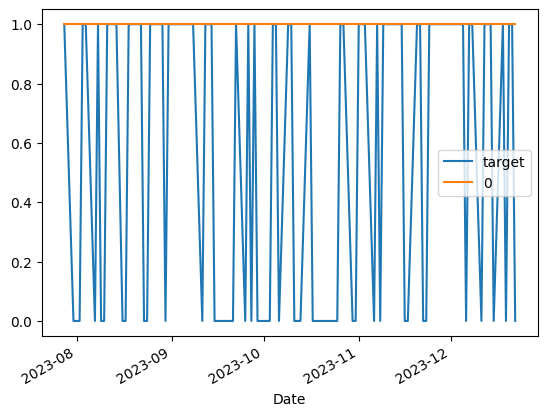

In [11]:
# Combining target and predictions for visualization
combined = pd.concat([test["target"], preds], axis=1)
combined.plot()

In [12]:
# Function to make predictions
def predict(train, test, x, model):
    model.fit(train[x], train["target"])
    preds = model.predict(test[x])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["target"], preds], axis=1)
    return combined

In [13]:
# Function for backtesting
def backtest(data, model, x, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i + step)].copy()
        predictions = predict(train, test, x, model)
        all_predictions.append(predictions)

    return pd.concat(all_predictions)

In [14]:
# Running backtest
predictions = backtest(nse, model, x)

In [15]:
# Displaying results
predictions["Predictions"].value_counts()
predictions["target"].value_counts() / predictions.shape[0]
precision_score(predictions["target"], predictions["Predictions"])
predictions

,target,Predictions
Date,,
2017-12-08 00:00:00+05:30,1,1
2017-12-11 00:00:00+05:30,0,1
2017-12-12 00:00:00+05:30,0,1
2017-12-13 00:00:00+05:30,1,1
2017-12-14 00:00:00+05:30,1,1
...,...,...
2023-12-18 00:00:00+05:30,1,0
2023-12-19 00:00:00+05:30,0,0
2023-12-20 00:00:00+05:30,1,0


In [16]:
# Getting user input for the features
user_close = float(input("Enter the closing price: "))
user_open = float(input("Enter the opening price: "))
user_high = float(input("Enter the high price: "))
user_low = float(input("Enter the low price: "))
user_volume = float(input("Enter the volume: "))

# Creating a DataFrame with the user input
user_data = pd.DataFrame({
    'Close': [user_close],
    'Open': [user_open],
    'High': [user_high],
    'Low': [user_low],
    'Volume': [user_volume]
})

# Making predictions using the trained model
user_predictions = model.predict(user_data)

# Displaying the predictions
print("Predictions:", user_predictions)



ValueError: could not convert string to float: ''

In [17]:
import pickle

# Save the trained model to a file using pickle
with open('random_forest_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

# Now the model is saved in 'random_forest_model.pkl'
